## Часть 2
### Проверка на нормальность

Источник данных: https://tochno.st/datasets/regions_collection - социально-экономические показатели регионов России

Задача: определить, является ли распределение количества совершенных преступлений нормальным

H0: распределение является нормальным

H1: распределение не является нормальным

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
economics_df = pd.read_csv("data/data_regions_collection_102_v20250605.csv", sep=";")

Группировка данных о преступности по регионам:

In [4]:
crime = economics_df[(economics_df["subsection"] == "Число лиц, потерпевших от преступных посягательств")
                   & (economics_df["object_level"] == "регион")][["indicator_name", "object_name", "indicator_value", "year"]]
crime_grouped = crime.groupby("object_name")["indicator_value"].mean()
crime_grouped[:3]

object_name
Алтайский край           28165.5
Амурская область         12220.5
Архангельская область    12507.0
Name: indicator_value, dtype: float64

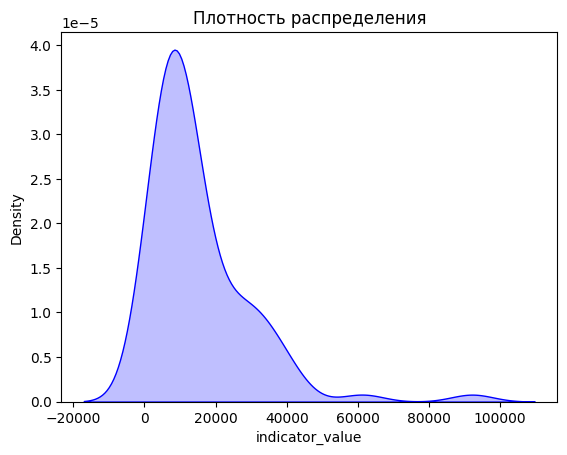

In [6]:
sns.kdeplot(crime_grouped, fill=True, color="blue", bw_adjust=1.0)
plt.title("Плотность распределения")
plt.show()

array([[<Axes: title={'center': 'indicator_value'}>]], dtype=object)

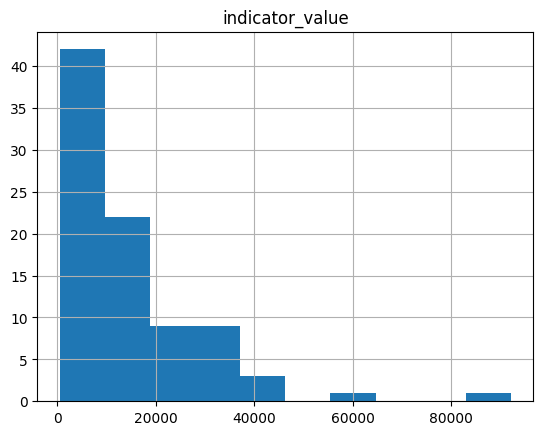

In [9]:
pd.DataFrame(crime_grouped).hist()

 #### Тест Колмогорова-Смирнова

In [9]:
from scipy.stats import kstwo

n = len(crime_grouped)
alpha = 0.05

res = stats.kstest(rvs=crime_grouped, cdf="norm")
print(f"""
статистика теста Колмогорова-Смирнова: {res.statistic}
p-value: {res.pvalue}
Критическое значение для n={n}: {kstwo.ppf(1 - alpha, n):.4f}""")


статистика теста Колмогорова-Смирнова: 1.0
p-value: 0.0
Критическое значение для n=87: 0.1435


p-value < 0.05, поэтому тест H0 отвергается.
Значение теста Колмогорова-Смирнова равно 1.0, что показывает сильное расхождение истонного распределения выборки от нормального

#### Тест Лиллиефорса

In [16]:
from statsmodels.stats.diagnostic import lilliefors

stat, p_value = lilliefors(crime_grouped)
print(f"""
статистика теста Лиллиефорса: {stat}
p-value: {p_value}""")


статистика теста Лиллиефорса: 0.18925250743089495
p-value: 0.0009999999999998899


p-value < 0.05, поэтому отвергаем H0.

#### Тест Шапиро-Уилка

In [15]:
res = stats.shapiro(crime_grouped)
print(f"""
статистика теста Шапиро-Уилка: {res.statistic}
p-value: {res.pvalue}""")


статистика теста Шапиро-Уилка: 0.7739423015079852
p-value: 3.045825222341193e-10


p-value < 0.5, поэтому отвергаем H0.

In [18]:
res = stats.chisquare(crime_grouped)
print(f"""
статистика теста Пирсона: {res.statistic}
p-value: {res.pvalue}""")


статистика теста Пирсона: 1166694.0628838376
p-value: 0.0


Во всех тестах значение p-value < 0.05, поэтому H0 отвергается.

Распределение числа преступлений не является нормальным, что видно по гистограмме выше. Внешний вид гистограммы значений и графика плотности распределения также говорит о том, что эта величина распределена не нормально, а скорее экспоненциально.